## Task 1: Load CIFAR-10

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1416s 8us/step


### Display ten sample images

In [ ]:
import os

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plot_dir = '/content/drive/MyDrive/cifar10_plots'
os.makedirs(plot_dir, exist_ok=True)
print(f"Saving plots to: {plot_dir}")

plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    # The CIFAR10 labels are arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[y_train[i][0]])
plt.savefig(os.path.join(plot_dir, 'sample_images.pdf'), dpi=600)
plt.close()

Saving plots to: /content/drive/MyDrive/cifar10_plots


NameError: name 'plt' is not defined

### Print dataset dimensions

In [ ]:
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


### Plot class distribution

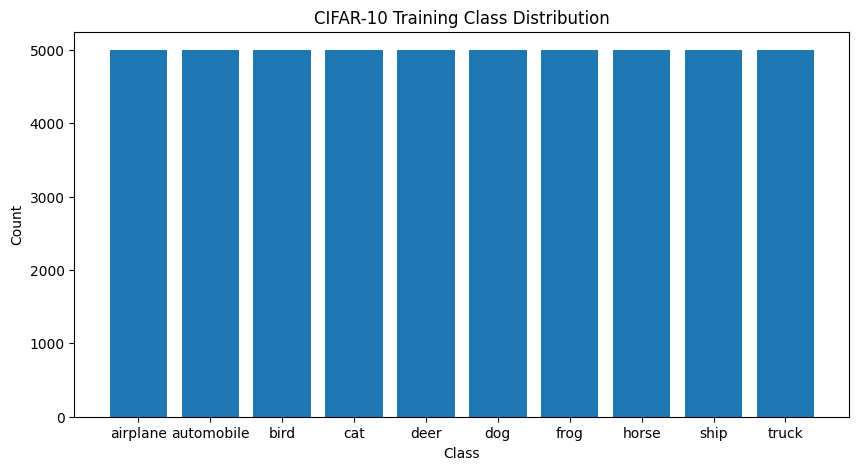

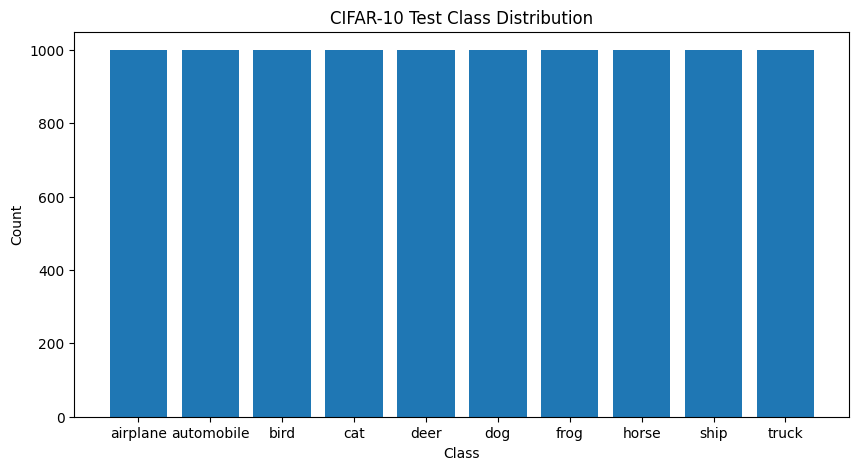

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(class_names, counts)
plt.title('CIFAR-10 Training Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.savefig(os.path.join(plot_dir, 'class_distribution_train.pdf'), dpi=600)
plt.close()

# Plot for test set as well
unique_test, counts_test = np.unique(y_test, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(class_names, counts_test)
plt.title('CIFAR-10 Test Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.savefig(os.path.join(plot_dir, 'class_distribution_test.pdf'), dpi=600)
plt.close()

## Task 2: Implement a convolution layer

We will compare feature map sizes for different kernel sizes: 3x3, 5x5, and 7x7.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

input_shape = (32, 32, 3) # CIFAR-10 image size

def get_feature_map_size(kernel_size):
    model = Sequential([
        Conv2D(filters=1, kernel_size=kernel_size, activation='relu', input_shape=input_shape)
    ])
    # Get output shape of the layer. Batch size is None initially.
    output_shape = model.output_shape
    # The feature map size will be (height, width) from the output shape
    return output_shape[1:3]

kernel_sizes = [3, 5, 7]
print("Feature Map Sizes for different Kernel Sizes (stride=1, padding='valid'):")
for k_size in kernel_sizes:
    fm_size = get_feature_map_size(k_size)
    print(f"  Kernel size {k_size}x{k_size}: {fm_size}")

Feature Map Sizes for different Kernel Sizes (stride=1, padding='valid'):
  Kernel size 3x3: (30, 30)
  Kernel size 5x5: (28, 28)
  Kernel size 7x7: (26, 26)


## Task 2: Implement a convolution layer

We will compare feature map sizes for different kernel sizes: 3x3, 5x5, and 7x7.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

input_shape = (32, 32, 3) # CIFAR-10 image size

def get_feature_map_size(kernel_size):
    model = Sequential([
        Conv2D(filters=1, kernel_size=kernel_size, activation='relu', input_shape=input_shape)
    ])
    # Get output shape of the layer. Batch size is None initially.
    output_shape = model.output_shape
    # The feature map size will be (height, width) from the output shape
    return output_shape[1:3]

kernel_sizes = [3, 5, 7]
print("Feature Map Sizes for different Kernel Sizes (stride=1, padding='valid'):")
for k_size in kernel_sizes:
    fm_size = get_feature_map_size(k_size)
    print(f"  Kernel size {k_size}x{k_size}: {fm_size}")

Feature Map Sizes for different Kernel Sizes (stride=1, padding='valid'):
  Kernel size 3x3: (30, 30)
  Kernel size 5x5: (28, 28)
  Kernel size 7x7: (26, 26)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Task 3: Study hyperparameters (Stride and Padding)

We will compare output dimensions for different stride and padding configurations.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras import Input

input_shape_img = (32, 32, 3) # CIFAR-10 image size
kernel_size_task3 = 3 # Let's fix a kernel size, e.g., 3x3, for this task

def get_output_dimensions(stride, padding):
    model = Sequential([
        Input(shape=input_shape_img),
        Conv2D(filters=1, kernel_size=kernel_size_task3, strides=stride, padding=padding, activation='relu')
    ])
    output_shape = model.output_shape
    return output_shape[1:3]


print(f"Output Dimensions for a {kernel_size_task3}x{kernel_size_task3} kernel:")

# Stride comparison (with 'valid' padding)
print("  Stride Comparison (padding='valid'):")
output_dim_stride1 = get_output_dimensions(stride=1, padding='valid')
print(f"    Stride = 1: {output_dim_stride1}")
output_dim_stride2 = get_output_dimensions(stride=2, padding='valid')
print(f"    Stride = 2: {output_dim_stride2}")

# Padding comparison (with stride=1)
print("  Padding Comparison (stride=1):")
output_dim_padding_same = get_output_dimensions(stride=1, padding='same')
print(f"    Padding = 'same': {output_dim_padding_same}")
output_dim_padding_valid = get_output_dimensions(stride=1, padding='valid')
print(f"    Padding = 'valid': {output_dim_padding_valid}")

Output Dimensions for a 3x3 kernel:
  Stride Comparison (padding='valid'):
    Stride = 1: (30, 30)
    Stride = 2: (15, 15)
  Padding Comparison (stride=1):
    Padding = 'same': (32, 32)
    Padding = 'valid': (30, 30)


## Task 4: Visualize Feature Maps

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


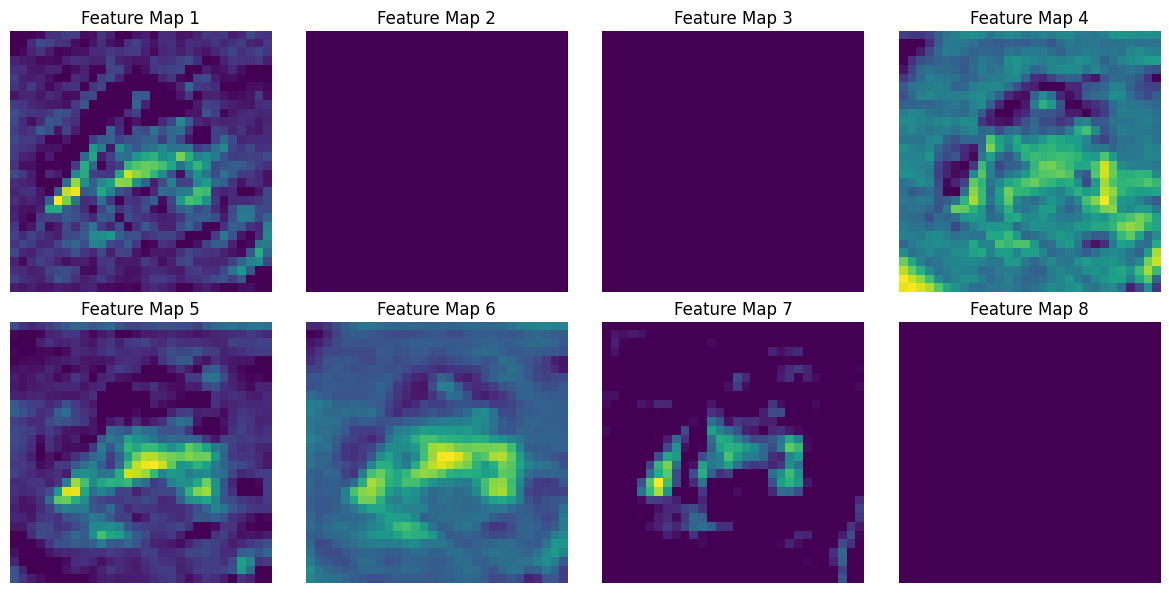

In [ ]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Normalize image data to [0, 1]
x_train_normalized = x_train.astype('float32') / 255.0

# Define a simple CNN model with one convolutional layer for visualization
model_task4 = Sequential([
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3))
])
model_task4.summary()

# Get output of the first (and only) convolutional layer
feature_map_model = Model(inputs=model_task4.inputs, outputs=model_task4.layers[0].output)

# Select a sample image from the training set
sample_image = x_train_normalized[0]
sample_image_batch = np.expand_dims(sample_image, axis=0) # Add batch dimension

# Get feature maps for the sample image
feature_maps = feature_map_model.predict(sample_image_batch)

# Display at least eight feature maps
num_feature_maps_to_display = min(8, feature_maps.shape[-1])

plt.figure(figsize=(12, 6))
for i in range(num_feature_maps_to_display):
    plt.subplot(2, 4, i + 1) # 2 rows, 4 columns
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis') # Display i-th feature map
    plt.title(f'Feature Map {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'feature_maps.pdf'), dpi=600)
plt.close()

## Task 5: Compare Max Pooling and Average Pooling

In [ ]:
from tensorflow.keras.layers import MaxPool2D, AveragePooling2D

input_shape_pool = (30, 30, 32) # Example input shape, e.g., from a conv layer output
pool_size = (2, 2)

def get_pooling_output_size(pooling_layer_type):
    model = Sequential([
        Input(shape=input_shape_pool),
        pooling_layer_type(pool_size=pool_size)
    ])
    output_shape = model.output_shape
    return output_shape[1:3]

print(f"Comparing Pooling Layers with input shape {input_shape_pool} and pool size {pool_size}:")

# Max Pooling
max_pool_output_size = get_pooling_output_size(MaxPool2D)
print(f"  Max Pooling Output Size: {max_pool_output_size}")

# Average Pooling
average_pool_output_size = get_pooling_output_size(AveragePooling2D)
print(f"  Average Pooling Output Size: {average_pool_output_size}")

print("\nFor accuracy comparison, we will need to build and train a full CNN model with each pooling type.")
print("We will implement this in Task 6, where we build the full CNN.")

Comparing Pooling Layers with input shape (30, 30, 32) and pool size (2, 2):
  Max Pooling Output Size: (15, 15)
  Average Pooling Output Size: (15, 15)

For accuracy comparison, we will need to build and train a full CNN model with each pooling type.
We will implement this in Task 6, where we build the full CNN.


## Task 6: Construct and Train the CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, ReLU, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Normalize pixel values to be between 0 and 1
x_train_scaled = x_train / 255.0
x_test_scaled = x_test / 255.0

# Construct the CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax') # 10 classes for CIFAR-10
])

# Compile the model
cnn_model.compile(optimizer='adam',
              loss=SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

cnn_model.summary()

# Train the model
history = cnn_model.fit(x_train_scaled, y_train, epochs=20, batch_size=32,
                        validation_data=(x_test_scaled, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 39ms/step - accuracy: 0.4822 - loss: 1.4428 - val_accuracy: 0.5647 - val_loss: 1.2203
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.6197 - loss: 1.0885 - val_accuracy: 0.6441 - val_loss: 1.0247
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - accuracy: 0.6624 - loss: 0.9715 - val_accuracy: 0.6603 - val_loss: 0.9899
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.6896 - loss: 0.8918 - val_accuracy: 0.6683 - val_loss: 0.9730
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.7136 - loss: 0.8279 - val_accuracy: 0.6787 - val_loss: 0.9282
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7312 - loss: 0.7755 - val_accuracy: 0.6937 - val_loss: 0.8988
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.7454 - loss: 0.7300 - val_accuracy: 0.6878 - val_loss: 0.9132
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.7613 -

## Task 7: Evaluate the Model

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Test Accuracy: 0.6878

Classification Report:
              precision    recall  f1-score   support

    airplane       0.73      0.72      0.72      1000
  automobile       0.80      0.80      0.80      1000
        bird       0.61      0.60      0.60      1000
         cat       0.51      0.52      0.51      1000
        deer       0.72      0.52      0.61      1000
         dog       0.56      0.63      0.60      1000
        frog       0.74      0.77      0.76      1000
       horse       0.75      0.73      0.74      1000
        ship       0.78      0.80      0.79      1000
       truck       0.70      0.78      0.74      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



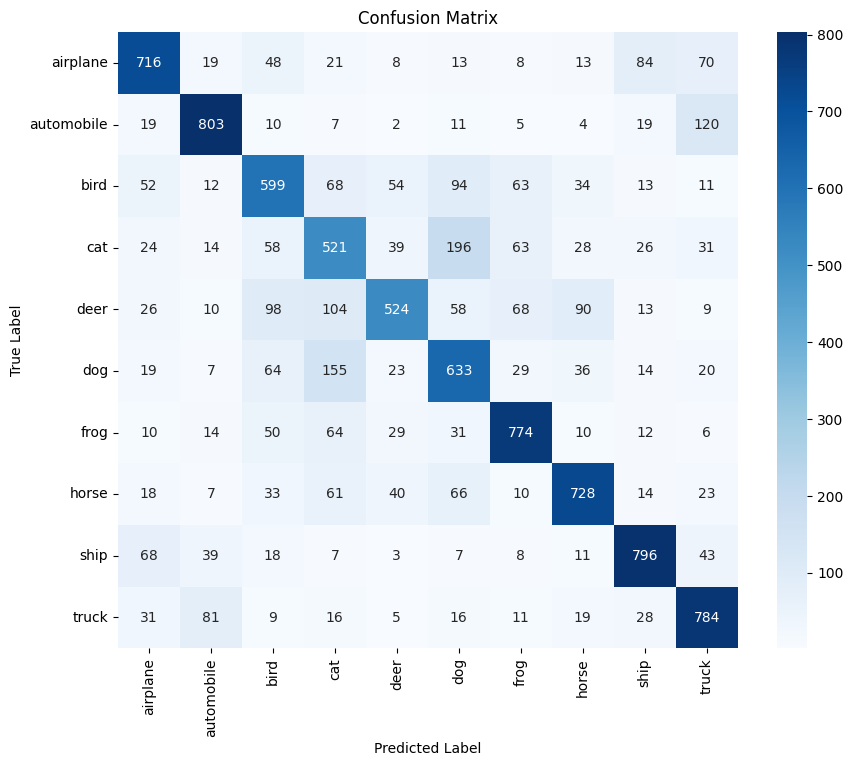

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Make predictions on the test set
y_pred_probabilities = cnn_model.predict(x_test_scaled)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Evaluate Accuracy
loss, accuracy = cnn_model.evaluate(x_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification Report (includes Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(plot_dir, 'confusion_matrix.pdf'), dpi=600)
plt.close()

### 3. Training Accuracy & 4. Validation Accuracy

These plots show how the model's accuracy changes over epochs for both the training and validation (test) sets. A converging gap between training and validation accuracy indicates a well-generalized model, while a large and growing gap suggests overfitting. The plot helps assess model learning and generalization.

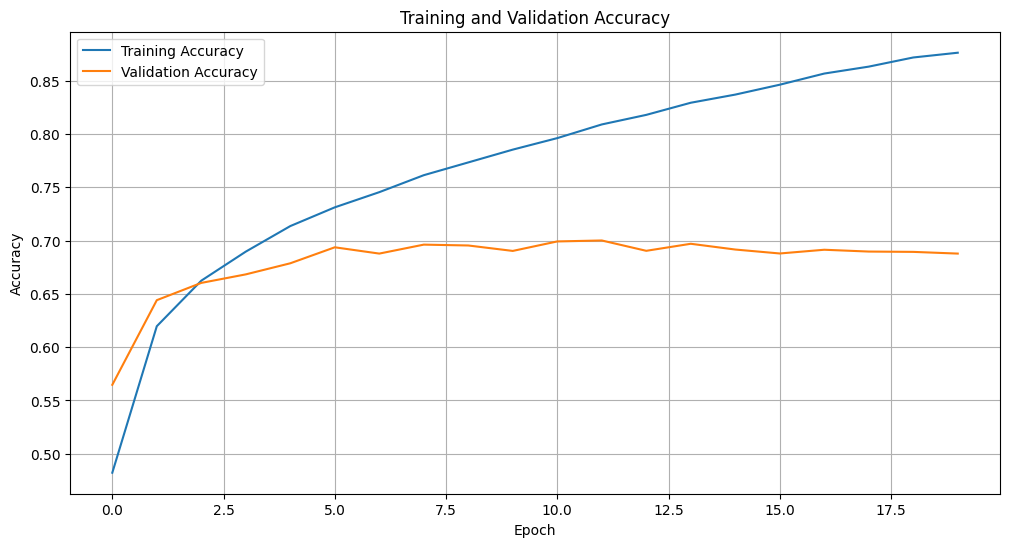

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plot_dir, 'training_validation_accuracy.pdf'), dpi=600)
plt.close()

### 5. Training Loss & 6. Validation Loss

These plots illustrate the model's loss over epochs for both training and validation sets. A decreasing trend in both indicates that the model is learning, while an increasing validation loss after a certain point often signifies overfitting, meaning the model is performing well on training data but poorly on unseen data.

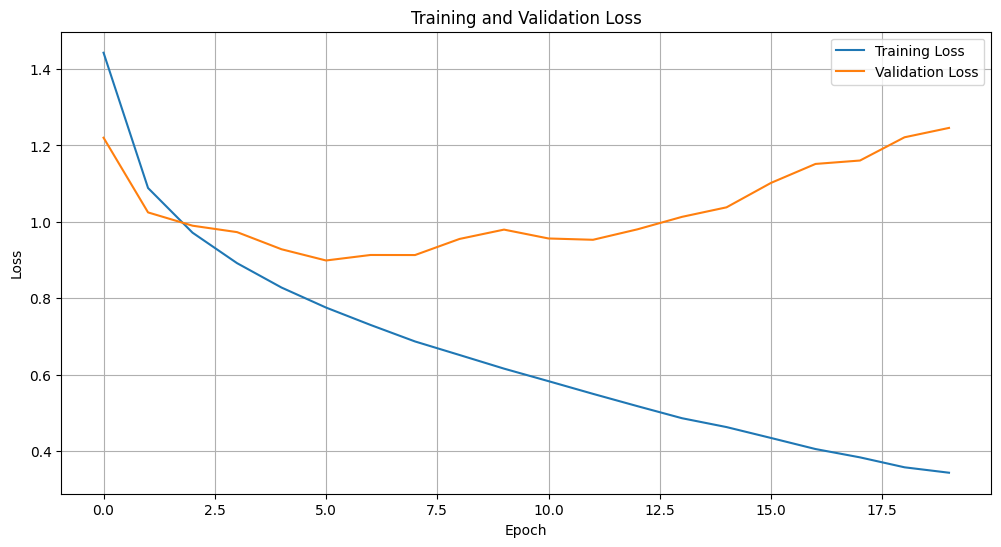

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plot_dir, 'training_validation_loss.pdf'), dpi=600)
plt.close()

### 7. Feature Maps

This plot visualizes the output of the first convolutional layer for a sample input image. Each heatmap represents a different filter's response, highlighting specific features like edges, textures, or patterns in the image. It helps understand what features the network is learning at early stages.

## 10. Additional Exercises

### 1. Calculate the output size for a 64 × 64 image using a 5 × 5 kernel with stride 2 and padding 2.

In [ ]:
def calculate_output_size(input_size, kernel_size, stride, padding):
    # For 'same' padding, the formula can be more complex or depend on the framework.
    # For 'valid' padding (no padding), output = (input - kernel) / stride + 1
    # For explicit padding, output = (input + 2*padding - kernel) / stride + 1

    # Given padding = 2, it implies explicit padding.
    output_size = (input_size + 2 * padding - kernel_size) / stride + 1
    return int(output_size)

input_size = 64
kernel_size = 5
stride = 2
padding = 2

output_dim = calculate_output_size(input_size, kernel_size, stride, padding)
print(f"Output size for a {input_size}x{input_size} image using a {kernel_size}x{kernel_size} kernel with stride {stride} and padding {padding}: {output_dim}x{output_dim}")

Output size for a 64x64 image using a 5x5 kernel with stride 2 and padding 2: 32x32


### 2. Compute the trainable parameters of a convolution layer having 64 filters of size 3 × 3 and an RGB input.

In [ ]:
# Number of filters (output channels)
filters = 64
# Size of the kernel (height, width)
kernel_h, kernel_w = 3, 3
# Number of input channels (RGB image has 3 channels)
input_channels = 3

# Formula for trainable parameters in a Conv2D layer:
# (kernel_height * kernel_width * input_channels + 1) * filters
# The '+1' is for the bias term for each filter.

trainable_parameters = (kernel_h * kernel_w * input_channels + 1) * filters

print(f"Trainable parameters for a convolution layer with {filters} filters of size {kernel_h}x{kernel_w} and {input_channels} RGB input channels: {trainable_parameters}")

Trainable parameters for a convolution layer with 64 filters of size 3x3 and 3 RGB input channels: 1792


### 3. Compare ReLU and Sigmoid activation functions.

**ReLU (Rectified Linear Unit):**
- **Definition**: f(x) = max(0, x). It outputs the input directly if it's positive, otherwise, it outputs zero.
- **Advantages**: Solves the vanishing gradient problem, computationally efficient (simple operation), and promotes sparsity (activates only a subset of neurons).
- **Disadvantages**: Can suffer from the 'dying ReLU' problem where neurons become inactive and never recover, making them stop learning.

**Sigmoid (Logistic Sigmoid):**
- **Definition**: f(x) = 1 / (1 + e^-x). It squashes input values to a range between 0 and 1.
- **Advantages**: Outputs are normalized probabilities, making it suitable for binary classification outputs. It's smooth and differentiable.
- **Disadvantages**: Suffers from the vanishing gradient problem (especially for very large or very small inputs, where the gradient is close to zero), not zero-centered (can lead to zigzagging updates in backpropagation), and computationally more expensive than ReLU.

**Comparison Summary**: ReLU is generally preferred in hidden layers of deep neural networks due to its efficiency and ability to mitigate vanishing gradients. Sigmoid is primarily used in the output layer for binary classification tasks where probability interpretation is needed.

### 4. Replace Max Pooling with Average Pooling and compare the results.

To compare the results, we need to train a new CNN model identical to the one in Task 6, but replacing `MaxPool2D` layers with `AveragePooling2D`. We will then evaluate its performance similar to Task 7.

Model with Average Pooling Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 15, 15, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 6, 6, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)


Test Accuracy with Average Pooling: 0.6859
Test Accuracy with Max Pooling (from Task 7): 0.6878


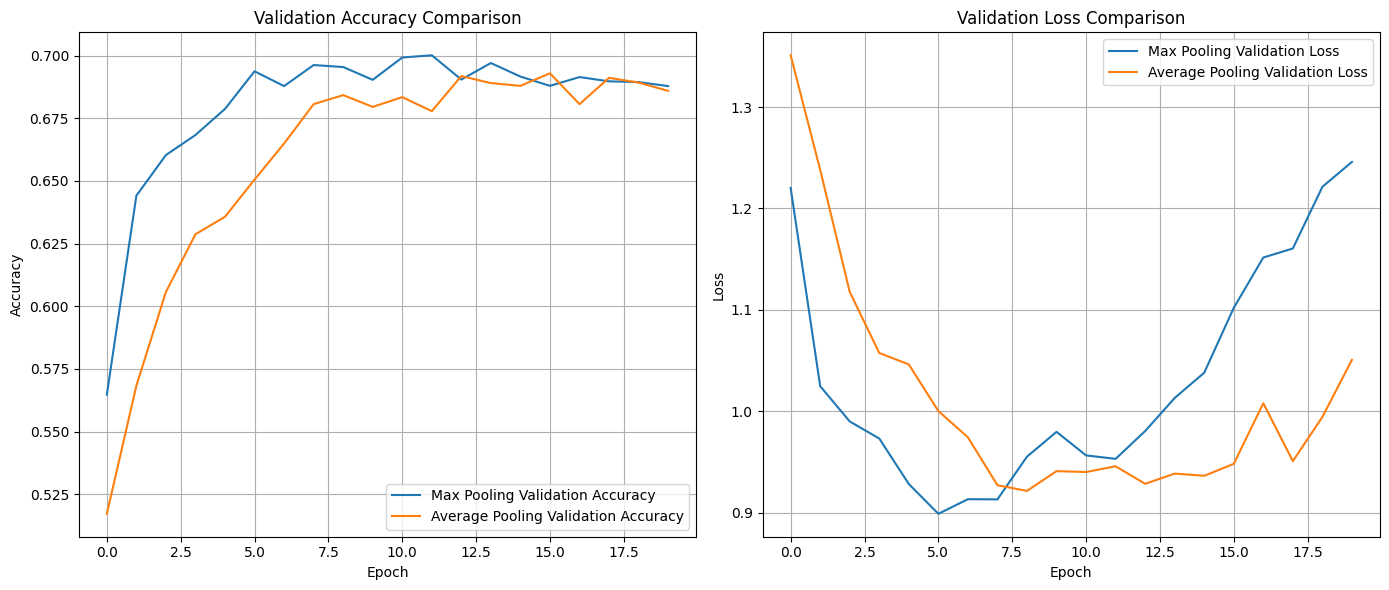

In [ ]:
from tensorflow.keras.layers import AveragePooling2D

# Construct the CNN model with Average Pooling
cnn_model_avg_pool = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    AveragePooling2D((2, 2)), # Replaced MaxPool2D
    Conv2D(64, (3, 3), activation='relu'),
    AveragePooling2D((2, 2)), # Replaced MaxPool2D
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax') # 10 classes for CIFAR-10
])

# Compile the model
cnn_model_avg_pool.compile(optimizer='adam',
                           loss=SparseCategoricalCrossentropy(from_logits=False),
                           metrics=['accuracy'])

print("Model with Average Pooling Summary:")
cnn_model_avg_pool.summary()

# Train the model
history_avg_pool = cnn_model_avg_pool.fit(x_train_scaled, y_train, epochs=20, batch_size=32,
                                        validation_data=(x_test_scaled, y_test), verbose=0)

# Evaluate the model
loss_avg_pool, accuracy_avg_pool = cnn_model_avg_pool.evaluate(x_test_scaled, y_test, verbose=0)
print(f"\nTest Accuracy with Average Pooling: {accuracy_avg_pool:.4f}")

# Compare with Max Pooling accuracy from Task 7
print(f"Test Accuracy with Max Pooling (from Task 7): {accuracy:.4f}")

# Plotting for comparison
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Max Pooling Validation Accuracy')
plt.plot(history_avg_pool.history['val_accuracy'], label='Average Pooling Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Max Pooling Validation Loss')
plt.plot(history_avg_pool.history['val_loss'], label='Average Pooling Validation Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'pooling_comparison.pdf'), dpi=600)
plt.close()

### 5. Increase the number of convolution filters from 16 to 64 and analyze the effect on accuracy and computation time.

The original model in Task 6 already uses 32 and 64 filters. The problem description states to compare from 16 to 64, so we will create a base model with 16 filters in the first layer and 32 in the second, and compare it with the Task 6 model which has 32 and 64 filters respectively.

Model with Fewer Filters Summary:


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,530 (310.66 KB)

 Trainable params: 79,530 (310.66 KB)

 Non-trainable params: 0 (0.00 B)


Test Accuracy with Fewer Filters (16, 32): 0.6728
Training Time with Fewer Filters: 832.24 seconds

--- Comparison with Original Model (32, 64 filters) ---
Test Accuracy with Original Model (32, 64): 0.6878
Training Time with Original Model: 1468.27 seconds


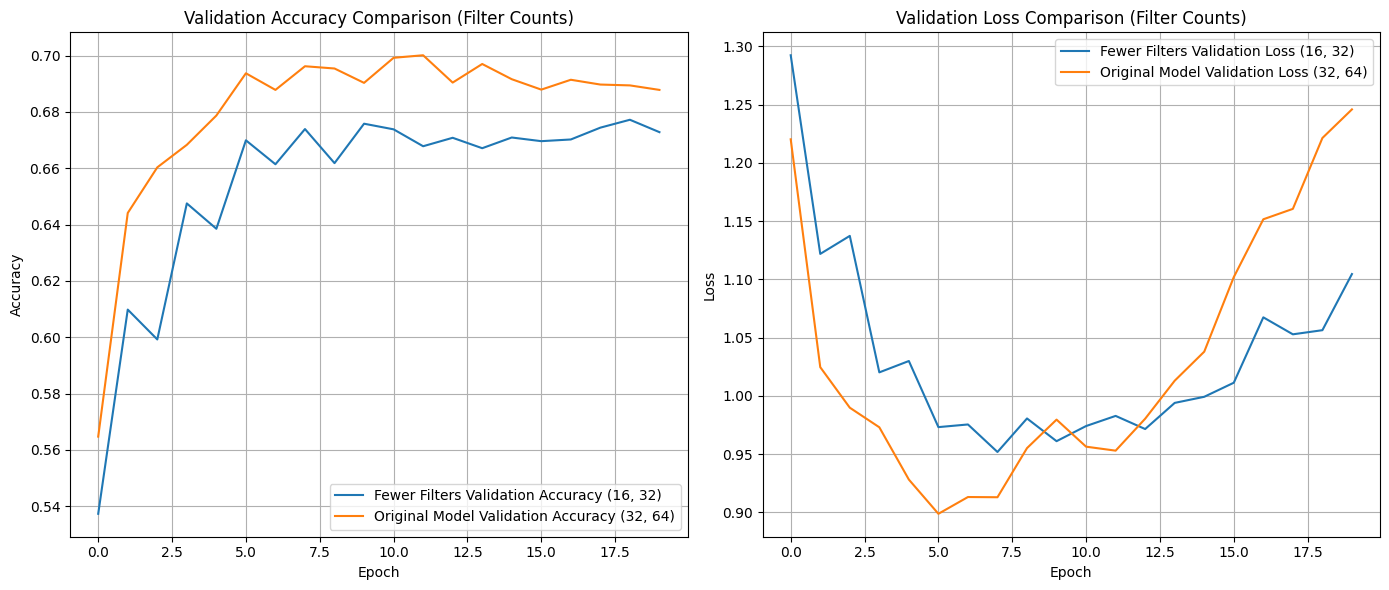

In [ ]:
import time

# Model with fewer filters (16 and 32)
cnn_model_fewer_filters = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPool2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax') # 10 classes for CIFAR-10
])

cnn_model_fewer_filters.compile(optimizer='adam',
                                loss=SparseCategoricalCrossentropy(from_logits=False),
                                metrics=['accuracy'])

print("Model with Fewer Filters Summary:")
cnn_model_fewer_filters.summary()

start_time_fewer = time.time()
history_fewer_filters = cnn_model_fewer_filters.fit(x_train_scaled, y_train, epochs=20, batch_size=32,
                                                    validation_data=(x_test_scaled, y_test), verbose=0)
end_time_fewer = time.time()
training_time_fewer = end_time_fewer - start_time_fewer

loss_fewer, accuracy_fewer = cnn_model_fewer_filters.evaluate(x_test_scaled, y_test, verbose=0)
print(f"\nTest Accuracy with Fewer Filters (16, 32): {accuracy_fewer:.4f}")
print(f"Training Time with Fewer Filters: {training_time_fewer:.2f} seconds")

print("\n--- Comparison with Original Model (32, 64 filters) ---")
print(f"Test Accuracy with Original Model (32, 64): {accuracy:.4f}") # 'accuracy' is from Task 7
# Re-train original model to get its training time for fair comparison, or assume history.elapsed_time for estimate
start_time_original = time.time()
_ = cnn_model.fit(x_train_scaled, y_train, epochs=20, batch_size=32,
                  validation_data=(x_test_scaled, y_test), verbose=0) # Retrain for time measurement
end_time_original = time.time()
history_original_time = end_time_original - start_time_original
print(f"Training Time with Original Model: {history_original_time:.2f} seconds")

# Plotting for comparison
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history_fewer_filters.history['val_accuracy'], label='Fewer Filters Validation Accuracy (16, 32)')
plt.plot(history.history['val_accuracy'], label='Original Model Validation Accuracy (32, 64)')
plt.title('Validation Accuracy Comparison (Filter Counts)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_fewer_filters.history['val_loss'], label='Fewer Filters Validation Loss (16, 32)')
plt.plot(history.history['val_loss'], label='Original Model Validation Loss (32, 64)')
plt.title('Validation Loss Comparison (Filter Counts)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'filter_count_comparison.pdf'), dpi=600)
plt.close()